# Project Group 3 

Members: 
Youri Beijer 
Ecem Tyurkay 
Rico de Jong 
Saumitra Deo 
Pranshu Sharma 

Student numbers: 
4965027
6301207
5348870
6434223
6505015

# Research Objective

*Requires data modeling and quantitative research in Transport, Infrastructure & Logistics*

The aim of this report is to answer the following research question:

"How is rail freight distributed across European countries by consignment type and commodity group, and how does the railway network influence these patterns/trends?"

To address the main research question in a structured way, it is divided into several sub-questions, each focusing on a specific aspect of freight distribution, commodity and network influence.

1. How do different countries relate to different shares of consignment types?

2. How does network density influence consignment type? 

3. How does the network length influence the modal share?

4. Which top-5 and bottom- 5 EU countries have the most and least train freight?

5. How has the trend of full train consignments changed over time in the top and bottom-five EU freight countries?

6. How do commodity groups (NST 2007 classification) influence the distribution of consignment types?


# Data Used

rail_go_consgmt – Goods transported by type of consignment (Eurostat).

rail_go_grpgood – Goods transported by group of goods (Eurostat, NST 2007 classification, from 2008 onwards).

rail_if_line_na – Length of electric and non-electric railway lines, by nature of transport (Eurostat).

Rail_go_total – Eurostat indicators for total freight transported.

tran_hv_frmod – Eurostat statistics on the modal split of freight transport.

ttr00006 - Total railway network length recorded and submitted to eurostat.

# Data Pipeline

**1. Data Collection**

Download datasets from Eurostat (rail_go_consgmt, rail_go_grpgood, rail_if_line_na, freight volumes, modal share).

Ensure consistent formats (CSV/Excel).

**2. File Path Setup**
Defined a base directory for Eurostat data files and safely constructed full file paths using os.path.join.
Created a dictionary (files) containing paths to all relevant Eurostat freight datasets (e.g., rail freight volumes, modal share, line length, consignment, and goods groups).

**3. Country Selection**
Defined an updated list of EU27 countries + Switzerland (as of 2025) for filtering and standardizing dataset coverage.
Excluded non-EU countries (e.g., turkey) to maintain consistency with EU-level statistics.

**4. Data Merging**
Standardize country names, years, decide on units for obs_values. Filter to the required timeframe (2008 onwards).
Append raw data obs_values to each collumn and appropriatlty name it.

The notebook for steps 1-4 can be found **HERE**

**5. Data Storage & Versioning**
Store cleaned datasets in your GitHub repository.

Each member works on a separate branch, commits changes, and documents preprocessing steps.

**6. Additional reviewing missing data_consignment**
Imported the merged Eurostat dataset, containing all harmonized freight transport indicators.

Conducted a coverage matrix analysis to assess data completeness across countries and years — identifying where observations were missing for specific variables.

**7. Curve fitting (interpolation of missing data)**
Applied curve fitting as the interpolation method to estimate missing data points within each country’s time series.

Fitted appropriate mathematical functions (e.g., polynomial or exponential) to the observed data of each geopolitical entity, capturing unique national freight trends.

Used these fitted models to estimate missing values for key variables such as freight volume, modal share, and railway network length.

**8. Calculate confidense for each fit**
For each fit, calculated and recorded the uncertainty as a standard deviation, providing a quantitative measure of confidence for the interpolated values.

This approach ensured that all time series were both complete and analytically robust, while maintaining transparency about estimation uncertainty.

Visual and statistical checks confirmed that fitted curves followed realistic data patterns and avoided overfitting.

**9. Exporting addition document for consignment data**
Exported the finalized, curve-fitted dataset, including respective uncertainty metrics,  into a standardized CSV file for analytical use.

Stored the cleaned data and corresponding uncertainty records in the project’s structured “cleaned data” directory, versioned on GitHub for reproducibility.

This notebook provides the final, validated dataset with documented uncertainty, forming the foundation for subsequent statistical, econometric, and visualization analyses.

The notebook for steps 5-9 can be found **HERE**


# Sub-questions

To address the main research question in a structured way, it is divided into several sub-questions, each focusing on a specific aspect of freight distribution, commodity and network influence. Hypotheses formed already regarding these sub-questions and statistical methods will be used to test validity of these questions.


# 1 How do different countries relate to different shares of consignment types?

Within the case of consignment types within countries in the European Union for rail freight, there are primarily 2 types of identifiable data present on Eurostat. They are:

**Full Train Load:**
This consignment type comprises a single type of goods being transported by a single train, within a single integrated consignment note and wagon lists.

**Full Wagon Load:**
This consignment type comprises multiple types of goods being transported within a single train, with various consignment notes and wagon lists.

The countries being considered here are given in the following table along with their country codes for easier identification.

| Country     | Code |
|--------------|------|
| Switzerland  | CH   |
| Germany      | DE   |
| Italy        | IT   |
| Poland       | PL   |
| Sweden       | SE   |
| Slovenia     | SI   |
| Slovakia     | SK   |

These countries have been chosen for the analysis as the data for these were available to a larger extent as compared to other countries from the European Union. Few countries had some data missing for some years and hence its data has been interpolated and extrapolated in those cases.\
\
Considering the case of full train loads, the following plot has been obtained for the following.

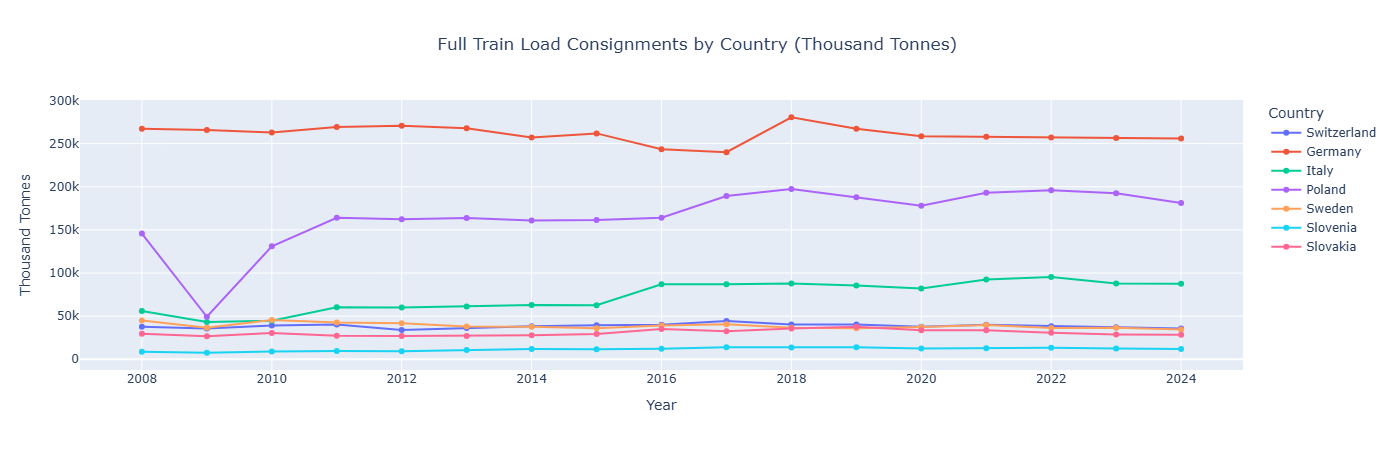

The output here describes the full train load that is carried in rail freight to the countries mentioned above. Here it is seen that Germany carries the largest quantity (Thousand Tonnes) of full train load consignment type while Slovenia has the least amount of full train loads being carried.Italy has shown a relatively steady increase in the amount of full load trains. Switzerland, Slovakia and Sweden have shown a steady trend of full train loads, with Slovakia showing signs of decline. Poland has witnessed a drastic drop from 2008 till 2009 but then gained it as quickly, showing resiliency. It remained stable before increasing and decreasing again till 2024, showing some signs of volatility even during its growth. Germany maintains the highest amount of full train loads. Germany having a large quantity of full train load indicates a large industrial presence within the country, which is expected and is required to meet the growing demands of it. An increasing demand from Italy also suggests a strong requirement for grains and industry raw materials or equipment for the country.

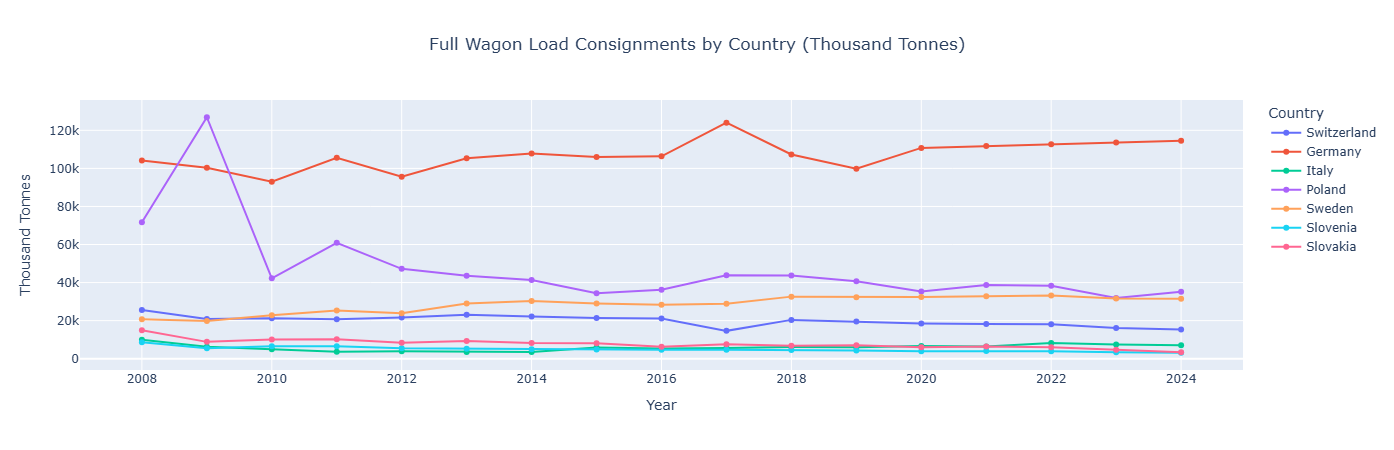

In the full wagon load consignments, Germany sees an overall increasing trend, barring the decline from 2017-2019 and again increasing since then. Switzerland, Slovakia, Slovenia and Italy have seen relatively lower levels of full wagon load consignments, which were decreasing. Poland has seen a drastic rise and fall in full wagon load consignments since 2010, which could be treated as an outlier considering the data trend thereafter. It continued to decrease further and brief periods of increase from 2016 till 2019. As from the previous graph, it becomes evident that Poland looks to shift to full train consignments instead to meet its demands and requirements.\
Sweden shows a modest rise in the use of full wagon loads , increasing from 23904 in 2012 to 31499 thousand tonnes in 2024, in full wagon load, marking an increase of 31.77 % in 12 years.

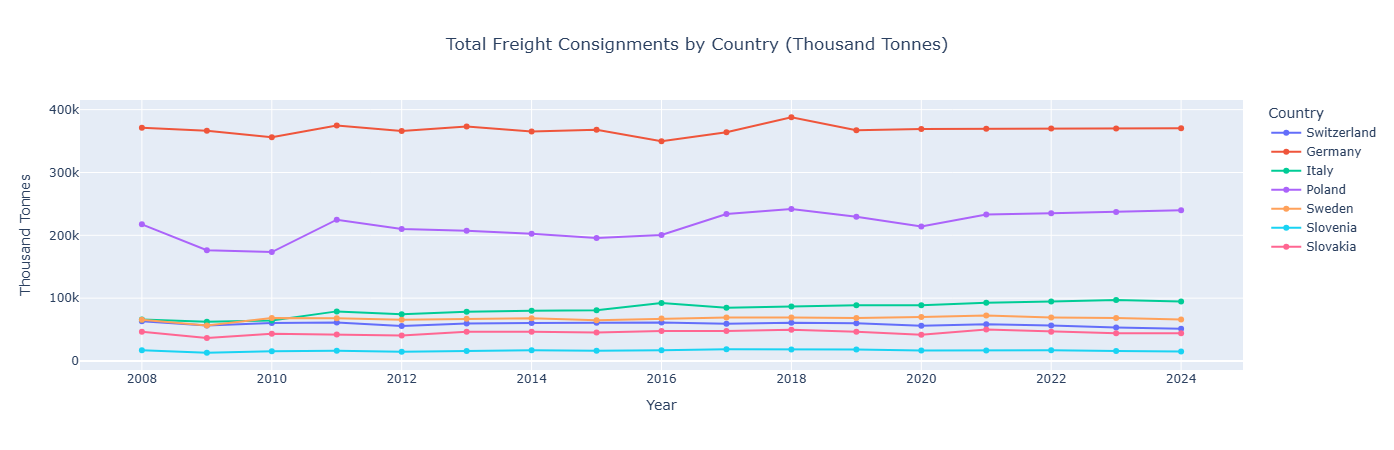

Through these graphs, we see that there is a growing demand for full train loads as compared to full wagon loads for industry and large-requirement centric countries such as Germany and Italy, as both display an increasing trend.\
Sweden, Slovenia and Slovakia have seen relatively stable freight volume trends, with some variations occurring in Sweden with respect to the Full wagon load consignment type (increasing trend).\
We also observe that the major share of freight consignments is dominated by Germany, then Poland,Italy and thereafter the remaining European countries.\

Given below is a heatmap of the distribuition of the full train load and full wagon load.

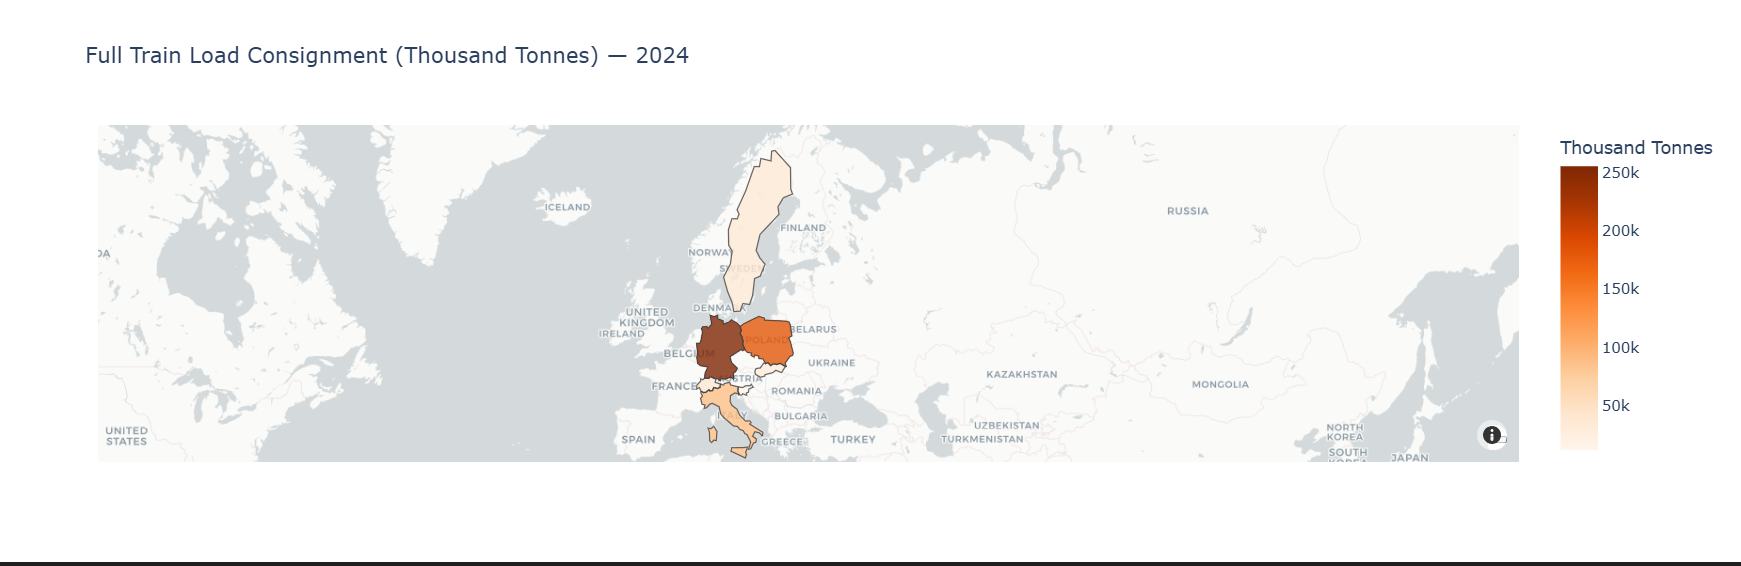

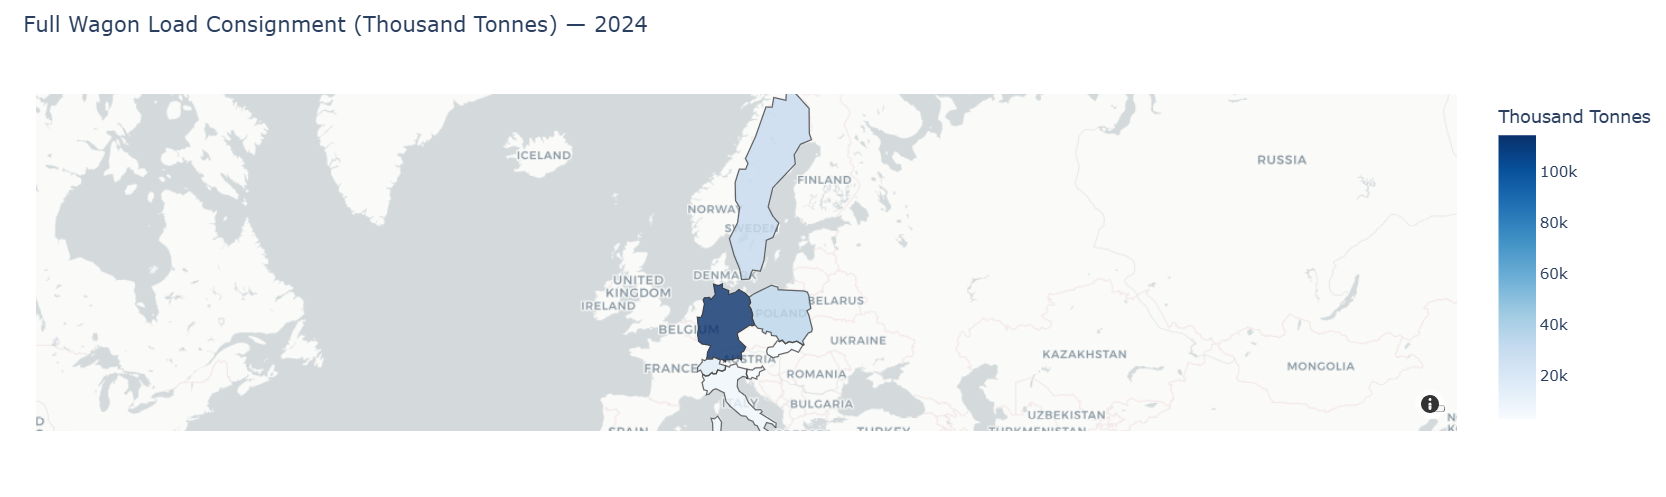

**Conclusions**

The chi-square test shows a statistic of 495,479 with 6 degrees of freedom and a p-value of 0.0. This indicates a significant association between country and the share of full train loads versus full wagon loads. Italy uses full train loads for 92% of its rail freight, while Sweden uses them for 58%. Other countries fall in between. Conclusion: the distribution of consignment types varies significantly across countries.


# 2 How does network density influence consignment type? 

This section explores how differences in network density and the extent of the transport network relative to population and geographic area affect the distribution of consignment types across European countries. Network density reflects the accessibility and capacity of the transport system, which can influence how freight is typically moved. 

**Data usage.**

All available data across the full time period were used in this analysis. Since the purpose of this sub-question is to test the relationship between network density and the distribution of consignment types rather than changes over time. Temporal variation is not relevant here. Including all years increases the robustness of the analysis by capturing the full range of observations. The evolution of these trends over time will be examined in a later sub-question, where temporal effects are explicitly considered. Two complementary measures of network density were used to capture different aspects of rail infrastructure distribution.

**Population-based network density** reflects the accessibility of the network to people. It provides insight into how well the existing infrastructure serves demand that originates from population concentration for instance, in densely populated countries where rail networks are heavily used for both passenger and freight transport.

**Area-based network density** captures the spatial coverage and physical extent of the network. This measure is important for understanding how the network supports long-distance freight operations and regional connectivity, especially in geographically large countries where infrastructure spread across an area determines freight mobility potential.


By comparing both density types, it becomes possible to distinguish between the effects of network accessibility, indicating how dense the infrastructure is relative to people, and network coverage ,indicating how dense it is relative to land area on the distribution of consignment types. This dual approach provides a more complete understanding of how infrastructure characteristics shape freight transport behaviour across European countries.

This analysis tests whether different measures of network density population-based and area-based have a measurable effect on the distribution of consignment types across European countries. Therefore the following hypotheses will be tested:
H₀₁: Network population density has no significant influence on the distribution of consignment types.


H₁₁: Network population density significantly influences the distribution of consignment types.


H₀₂: Network area density has no significant influence on the distribution of consignment types.


H₁₂: Network area density significantly influences the distribution of consignment types.

**The results.**

A scatterplot was selected as the most appropriate visualization technique because it effectively represents the relationship between two continuous variables network density and consignment volume. This format allows for the clear identification of general patterns, such as positive or negative trends, while also visualizing the dispersion and variability of data points across countries and years.
The scatterplots in Figures 3.2.2-1 and 3.2.2-2 visualize the relationship between network density and the distribution of consignment types.

![Figure 3.2.2-1: Relationship between network population density and consignment type](Charts/network_pop_density_vs_consignment.png)

The scatterplot in Figure 3.2.2-1 illustrates the relationship between network population density and consignment distribution. The results show a negative trend, suggesting that as rail accessibility relative to population increases, the total volume of freight transport decreases. This pattern indicates that countries with high population-based network density tend to be less freight-dependent and more oriented toward passenger services.

![Figure 3.2.2-2: Relationship between network area density and consignment type](Charts/network_area_density_vs_consignment.png)

In contrast, Figure 3.2.2-2 shows the relationship between network area density and consignment volume. Here, a positive association is observed countries with more spatially extensive rail networks tend to have higher total freight volumes and a greater proportion of full-train consignments. This implies a higher dependence of freight transport on the geographical coverage of the rail network. A denser spatial network supports long-distance, bulk, and industrial shipments, leading to a more uneven distribution of consignment types dominated by full-train loads.

The creation of both images can be found in **THIS NOTEBOOK**.

**Hypotheses testing.**

To verify these observed relationships, a Chi-Squared Test of Independence was conducted to statistically assess whether the distribution of consignment types differs significantly across categories of network density. The results of these tests are discussed in the following section. 
The first test, based on network population density, yielded a Chi-Squared statistic of χ²(2, N = 124) = 6.08, with a corresponding p-value = 0.0479. Since this value is slightly below the 0.05 threshold, the null hypothesis (H₀₁) can be rejected. This indicates a weak but statistically significant dependency between network density relative to population and the distribution of consignment types. In practical terms, this suggests that in countries with denser rail networks per capita, the distribution of freight consignments differs systematically likely due to greater accessibility and diversified transport use between passenger and freight services.

The second test, using network area density, produced χ²(2, N = 117) = 4.72, with a p-value = 0.0947. Because this result exceeds the 0.05 significance level, H₀₂ cannot be rejected, meaning that no statistically significant dependency was detected between network density per land area and consignment type distribution. Although the scatterplot in Figure 3.2.2-2 suggested a positive relationship, the statistical evidence is insufficient to confirm that the two variables are dependent at the 95% confidence level.

The confidense testing of this sub-question can be found in **THIS NOTEBOOK**.

**Conclusion. #2**

The analysis demonstrates that network density influences freight distribution in distinct ways depending on how it is measured. While spatial network coverage alone does not significantly affect the composition of consignments, population-based density shows a weak but notable dependency, indicating that the accessibility of rail infrastructure relative to population contributes to how freight transport is organized. It is important to note that some of the data points were obtained through interpolation and extrapolation using curve-fitting techniques, which introduces a degree of uncertainty into the analysis. Although standard deviations were included to quantify this uncertainty, these approximations may affect the precision of the statistical relationships.The calculated uncertainty values will be in appendix A.These findings suggest that rail network accessibility plays a subtle yet meaningful role in shaping freight behavior across Europe, linking infrastructure characteristics directly to the structure and scale of consignment movements.


# 3 How does the network length influence the modal share? 

# 4 Which top-5 and bottom- 5 EU countries have the most and least train freight?


# 5 How has the trend of full train consignments changed over time in the top and bottom-five EU freight countries?


# 6 How do commodity groups (NST 2007 classification) influence the distribution of consignment types?


# Conclusion

# Contribution Statement

Each author is responsible for answering their own sub-question.

**Author 1**: 
Saumitra Deo

"How do different countries relate to different shares of consignment types?"

Tasks: Extract relevant Eurostat data from the merged file, Clean and preprocess country–consignment data, Build contingency tables (country vs. consignment type), Perform chi-square test of independence, Create visualizations: bar charts, heatmaps of shares by country, Write results section discussing differences across countries.

**Author 2**:
Youri Beijer

"How does network density influence consignment?"

Tasks: Create a network density variable(s), cross reference network density to consignment type, Perform correlation analysis  between network density and consignment types, Run regression models to test influence of network length, Create scatter plots with regression lines, Document methodology and statistical findings.

Additionally: Youri Beijer was responsible for data merging and cleaning.

Merging tasks: Download all relevant data sets for each sub-question, Merge them into one csv creating collumns filled with observation values, Index them on geoplotical entities and years, Filter relevant geoplotical entities (EU + CH).

Cleaning tasks: Evaluate data coverage, Evaluate whether data reported by geopolitical entites is useable. Curve-fit NaN values of consignment types using all present data, record uncertainties.

**Author 3**:
Rico de Jong

"How does the network length influence the modal share?"

Tasks: Extract data on modal share of rail freight from the merged file, Link modal share with network length & density indicators, Conduct regression analysis (network length & density vs. modal share), Create scatter plots, regression plots, and comparative tables, Interpret whether denser networks show higher modal shares, Draft results and add visual evidence to the report.

**Author 4**:
Pranshu Sharma

"Which 5 EU countries have the most- and least train freight?"

Tasks: Extract rail freight volume dataset from the merged file, Rank countries and identify top 5 and bottom 5, Compare structural differences (total volume, growth trends), Produce tables, rankings, and bar plots of volumes, Write results section interpreting patterns among high vs. low performers.

**Author 5**:
Ecem Tyurkay

"How has the trend of full train consignments changed over time in the top- and bottom-five EU freight countries?"

Tasks: Filter dataset for full train consignments, Perform time-series analysis (2008–present), Plot trends for top 5 and bottom 5 countries (line charts, percentage shares), Test hypotheses using regression or trend analysis.

"How do commodity groups (NST 2007 classification) influence the distribution of consignment types?"

Tasks: Retrieve dataset (rail_go_grpgood) from the merged file, Build contingency tables (commodity group × consignment type), Run chi-square independence tests, Visualize with stacked bar charts and heatmaps, Interpret which commodity groups are linked to certain consignment types.